In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

from src.uncertainty.metrics.mutual_information import mutual_information
from src.uncertainty.metrics.entropy import binary_entropy
from src.uncertainty.metrics.variance import variance
from src.config_presets.tools.get_config import get_config


config = get_config('Daniel/VM_uncertainty')

endpoint_list = config['columns']['labels']

endpoint_list

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


['Dysphagia_M06']

In [75]:

ALL_DFS_DICT = {
    "Xerostomia_M06": {
        "MC Dropout" :    pd.read_csv("/home/macraedc/rt_pred_results/MC Dropout/Xerostomia_ResNet/model_1/all_predictions.csv", sep=';'),
        "Deep Ensemble":  pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Xerostomia_ResNet/all_predictions.csv", sep=';'),
        "TTA":            pd.read_csv("/home/macraedc/rt_pred_results/TTA/Xerostomia_ResNet/model_1/all_predictions.csv", sep=';')
    },
    "Dysphagia_M06": {
        "MC Dropout":     pd.read_csv("/home/macraedc/rt_pred_results/MC Dropout/Dysphagia_ResNet/model_1/all_predictions.csv", sep=';'),
        "Deep Ensemble":  pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Dysphagia_ResNet/all_predictions.csv", sep=';'),
        "TTA":            pd.read_csv("/home/macraedc/rt_pred_results/TTA/Dysphagia_ResNet/model_1/all_predictions.csv", sep=';')
        },
    # "OS_2year_censored" : {
    #     "MC Dropout":     pd.read_csv("/home/macraedc/rt_pred_results/MC Dropout/Baoqiang_OS_2year/model_1/all_predictions.csv", sep=';'),
    #     "Deep Ensemble":  pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Baoqiang_OS_2year/all_predictions.csv", sep=';'),
    #     "TTA":            pd.read_csv("/home/macraedc/rt_pred_results/TTA/Baoqiang_OS_2year/model_1/all_predictions.csv", sep=';')
    # },
    # "LRC_2year_censored": {
    #     "MC Dropout":     pd.read_csv("/home/macraedc/rt_pred_results/MC Dropout/Baoqiang_LRC_2year/model_1/all_predictions.csv", sep=';'),
    #     "Deep Ensemble":  pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Baoqiang_LRC_2year/all_predictions.csv", sep=';'),
    #     "TTA":            pd.read_csv("/home/macraedc/rt_pred_results/TTA/Baoqiang_LRC_2year/model_1/all_predictions.csv", sep=';')
    # }
}



UQ_RESULTS_DICT = {
    "Xerostomia_M06" : {},
    "Dysphagia_M06": {},
    #"OS_2year_censored": {},
    #"LRC_2year_censored": {}
                   }

ENDPOINT_TYPES = {
    "Xerostomia_M06": "Binary",
    "Dysphagia_M06": "Binary",
    "OS_2year_censored": "Binary",
    "LRC_2year_censored": "Binary"    
}


def compute_uncertainty_metrics_for_endpoint(df, endpoint):
#for endpoint in endpoint_list:
    df_UQ_results = pd.DataFrame(index=df.index)

    #label_columns = [x + '_true' for x in endpoint_list]
    endpoint_pred_columns = [col for col in df.columns if 'pred' in col]

    all_endpoint_preds = df[endpoint_pred_columns]
    #all_endpoint_preds = (all_endpoint_preds - all_endpoint_preds.min().min()) / (all_endpoint_preds.max().max() - all_endpoint_preds.min().min())
    mean_endpoint_preds = all_endpoint_preds.mean(axis=1)

    df_UQ_results["PatientID"] = df['PatientID']
    df_UQ_results['Mean Prediction'] = mean_endpoint_preds

    if ENDPOINT_TYPES[endpoint] == "Binary":
        df_UQ_results['True Labels'] = df[endpoint + '_true']
    else:
        df_UQ_results['True Label Event'] = df[endpoint + '_event_true'].values
        df_UQ_results['True Months Event'] = df[endpoint + '_months_true'].values
        
    df_UQ_results['Mutual Information'] = mutual_information(all_endpoint_preds)
    df_UQ_results['Binary Entropy'] = binary_entropy(mean_endpoint_preds)
    df_UQ_results['Variance'] =  variance(all_endpoint_preds)

    return df_UQ_results


test_set_patient_IDs = df_UQ_results['PatientID'].values.tolist()

df_dataset = pd.read_csv(r"/home/macraedc/data/MT_dataset_with_all_structs.csv", sep=';')
#df_dataset['Split'] = df_dataset['PatientID'].apply(lambda pid: 'test' if pid in test_set_patient_IDs else 'train_val')
#df_dataset.to_csv(r"/home/macraedc/data/MT_dataset_with_all_structs.csv", sep=';', index=False)
clinical_groups = ["Loctum2", "RT_modality", "Protons", "Systemic_treatment"]
df_dataset = df_dataset[['PatientID'] + clinical_groups]
df_dataset['Systemic_treatment'].replace("concomitante chemoradiatie", "Chemoradiation", inplace=True)

for endpoint, dfs in ALL_DFS_DICT.items():
    
    #pred_columns_dict = {endpoint: [col for col in df_MC_Xerostomia.columns if endpoint+"_pred" in col] for endpoint in endpoint_list}
    
    for method, df_all_preds in dfs.items():
        # label_columns = [x + '_true' for x in endpoint_list]
        # pred_columns = [col for col in dfs.columns if 'pred' in col]

        df_UQ_results = compute_uncertainty_metrics_for_endpoint(df_all_preds, endpoint)

        df_UQ_results = df_UQ_results.merge(df_dataset, on='PatientID', how='inner')
        UQ_RESULTS_DICT[endpoint][method] = df_UQ_results


UQ_methods_list = list(ALL_DFS_DICT["Dysphagia_M06"].keys()) 
UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]

/home/macraedc/tmp/ipykernel_1552446/3047187103.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_dataset['Systemic_treatment'].replace("concomitante chemoradiatie", "Chemoradiation", inplace=True)


In [76]:
df_dataset.Systemic_treatment.value_counts()

Systemic_treatment
RT alleen         823
Chemoradiation    491
Bioradiation       51
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

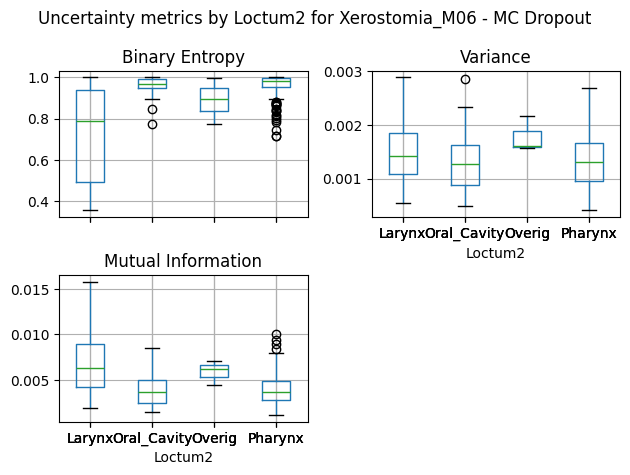

<Figure size 800x500 with 0 Axes>

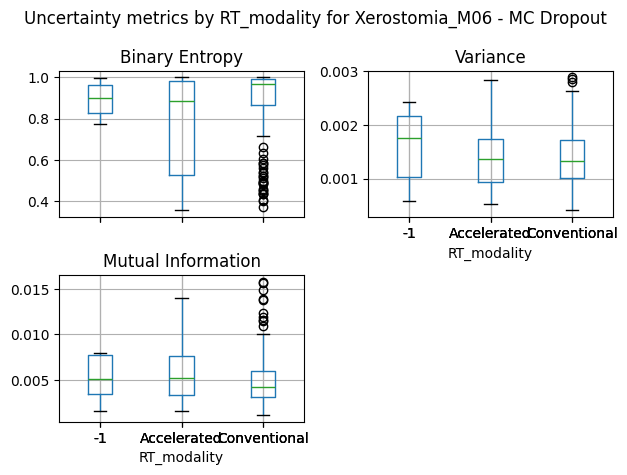

<Figure size 800x500 with 0 Axes>

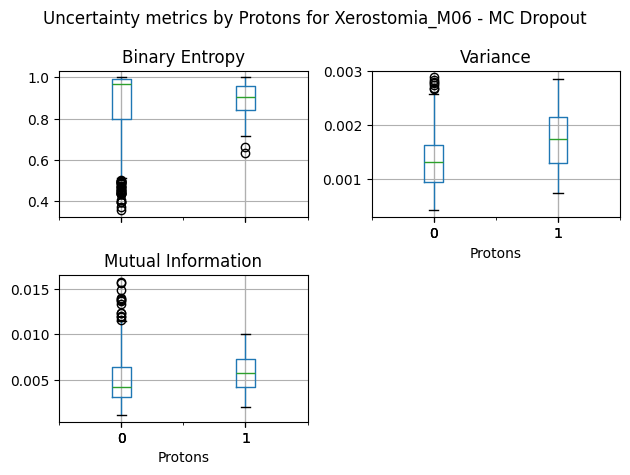

<Figure size 800x500 with 0 Axes>

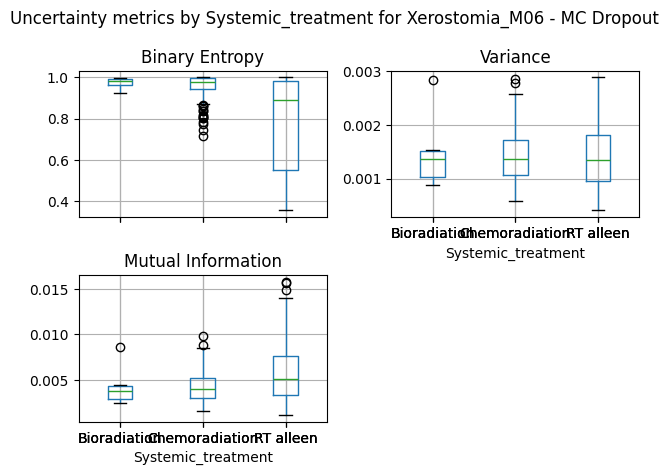

<Figure size 800x500 with 0 Axes>

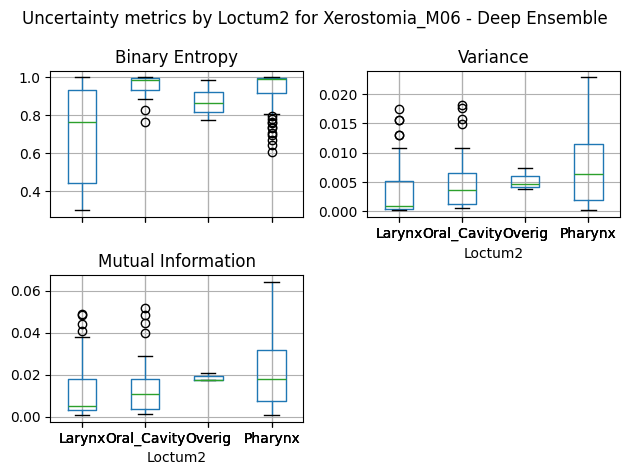

<Figure size 800x500 with 0 Axes>

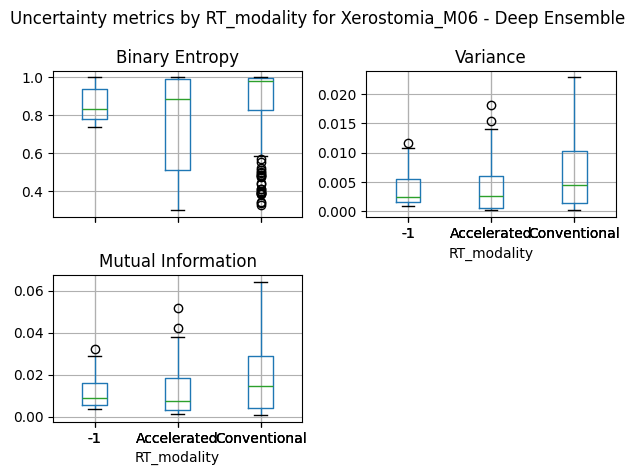

<Figure size 800x500 with 0 Axes>

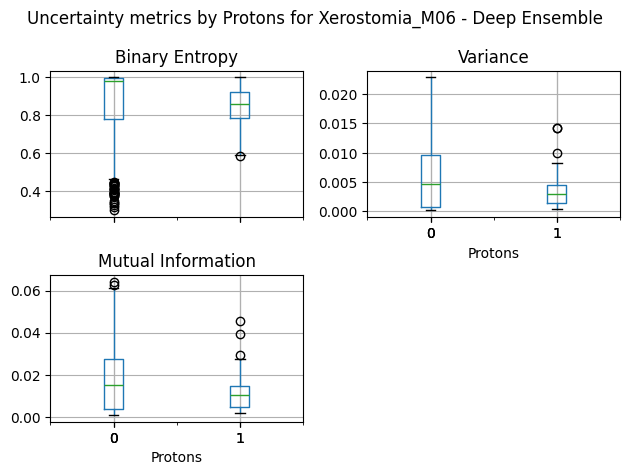

<Figure size 800x500 with 0 Axes>

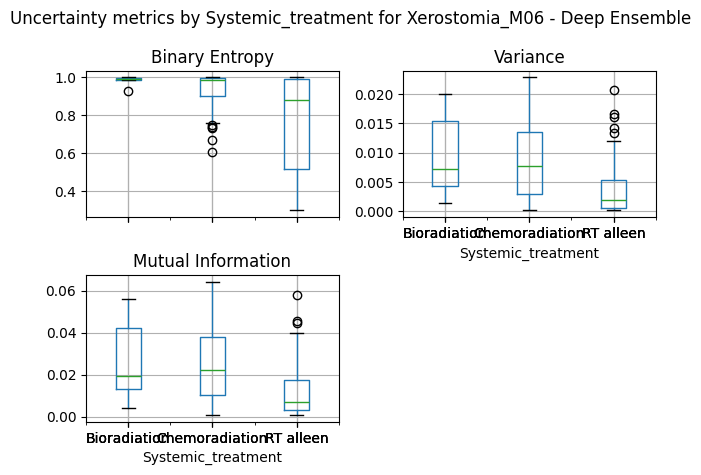

<Figure size 800x500 with 0 Axes>

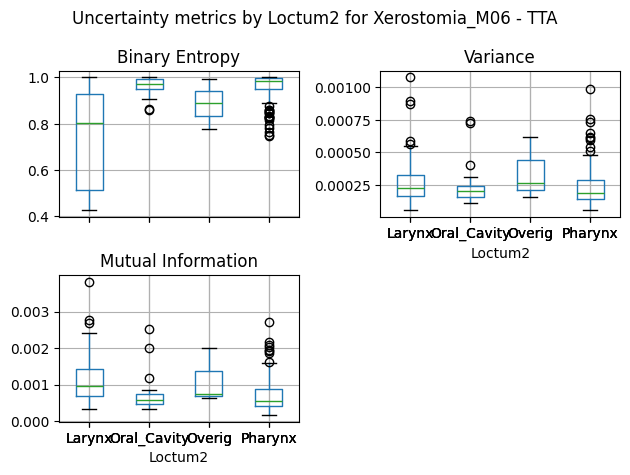

<Figure size 800x500 with 0 Axes>

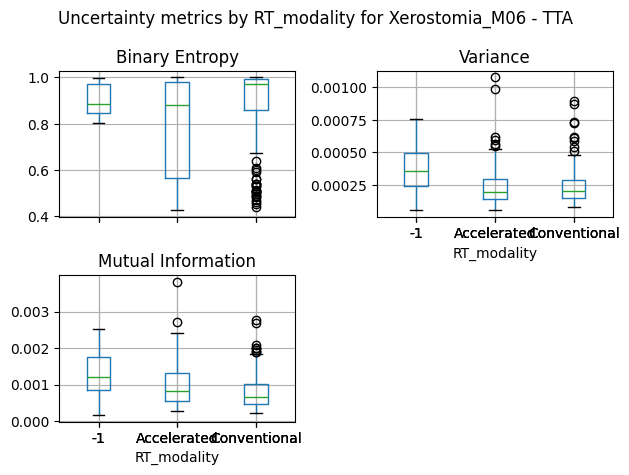

<Figure size 800x500 with 0 Axes>

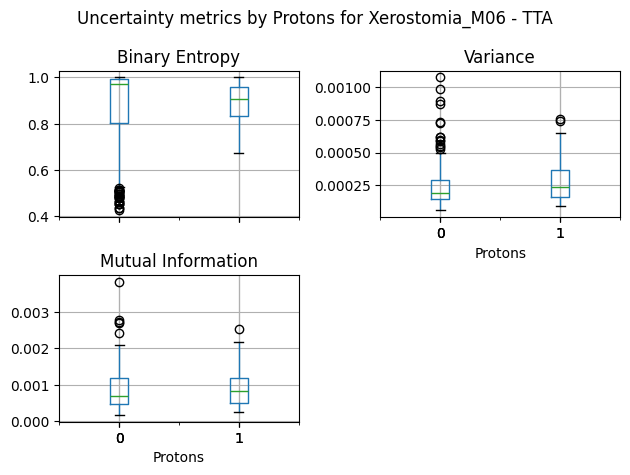

<Figure size 800x500 with 0 Axes>

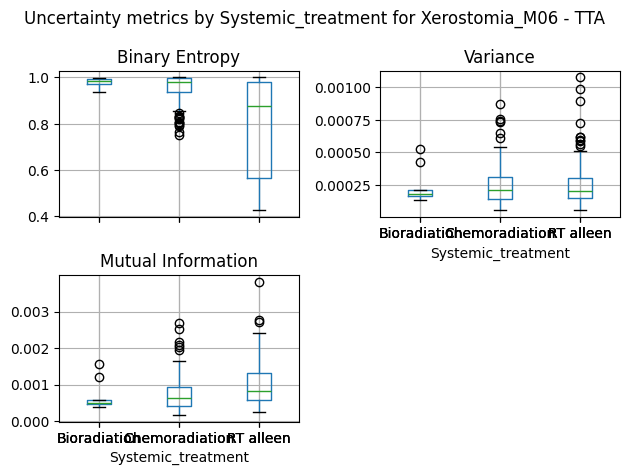

<Figure size 800x500 with 0 Axes>

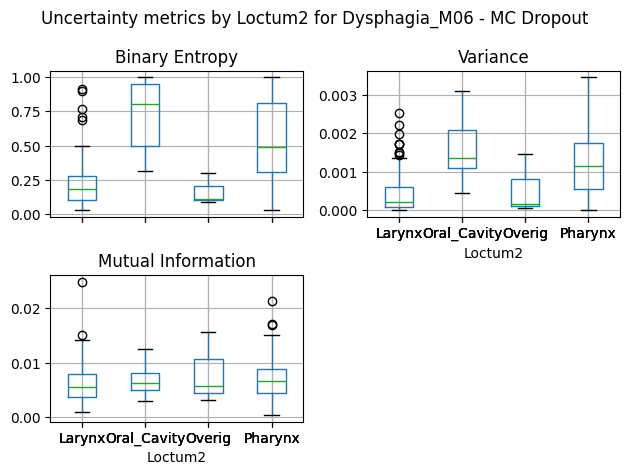

<Figure size 800x500 with 0 Axes>

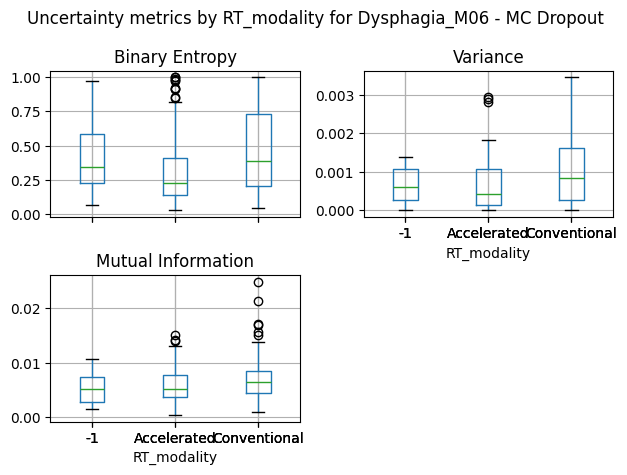

<Figure size 800x500 with 0 Axes>

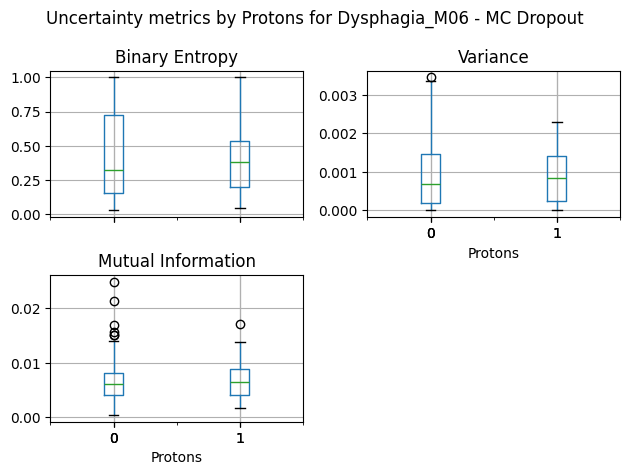

<Figure size 800x500 with 0 Axes>

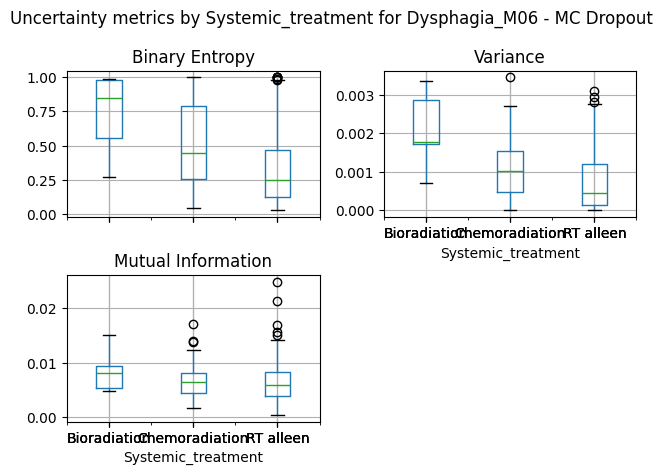

<Figure size 800x500 with 0 Axes>

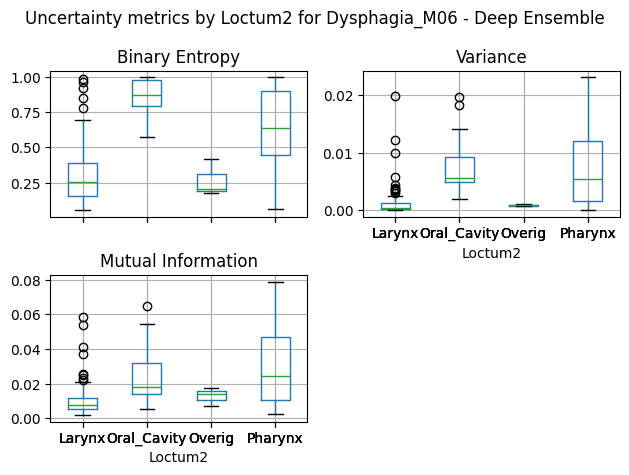

<Figure size 800x500 with 0 Axes>

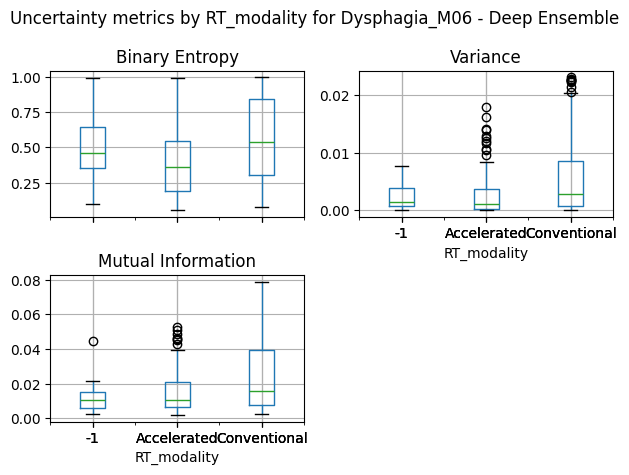

<Figure size 800x500 with 0 Axes>

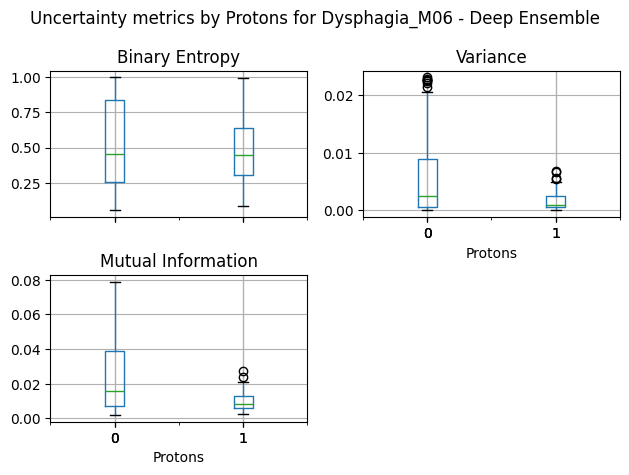

<Figure size 800x500 with 0 Axes>

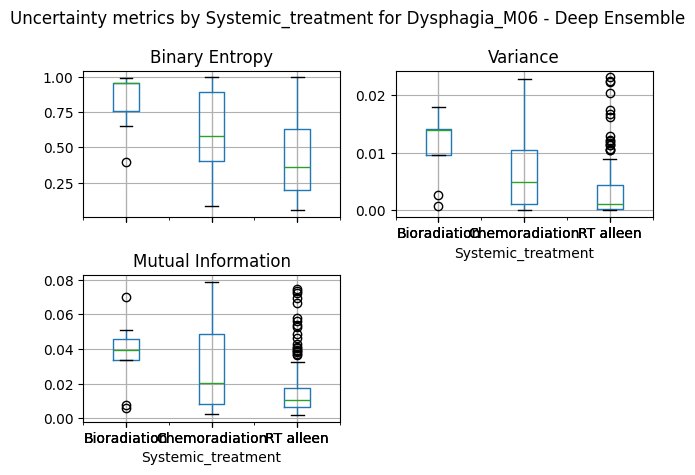

<Figure size 800x500 with 0 Axes>

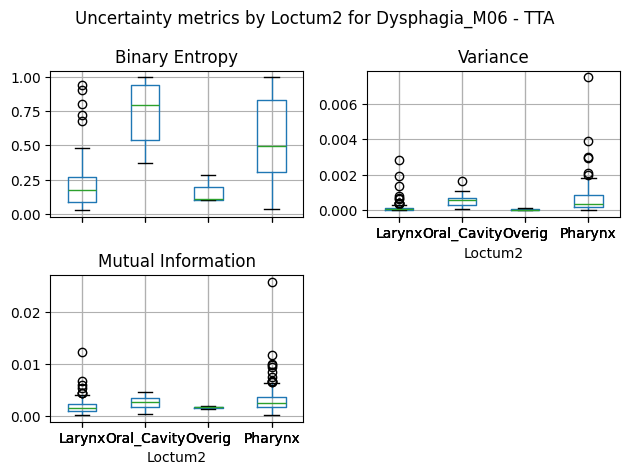

<Figure size 800x500 with 0 Axes>

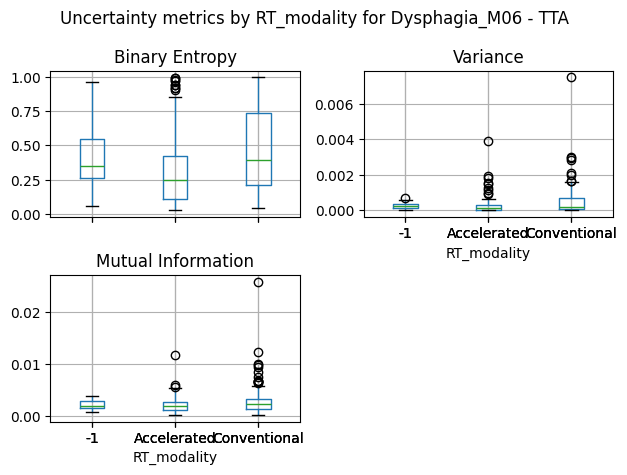

<Figure size 800x500 with 0 Axes>

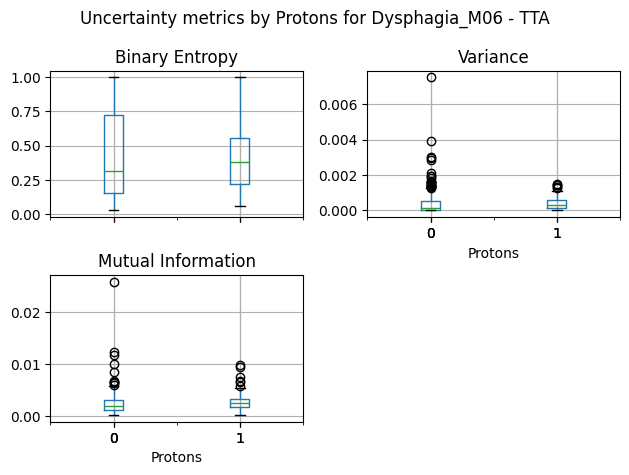

<Figure size 800x500 with 0 Axes>

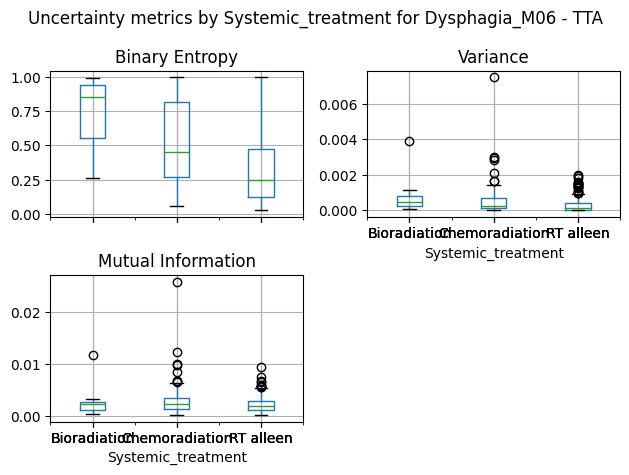

In [77]:
for endpoint in UQ_RESULTS_DICT.keys():
    for method in UQ_methods_list:
        df_UQ_results = UQ_RESULTS_DICT[endpoint][method]

        for group in clinical_groups:
            plt.figure(figsize=(8, 5))
            df_UQ_results.boxplot(column=UQ_metrics_list, by=group, sharey=False)
            plt.suptitle(f'Uncertainty metrics by {group} for {endpoint} - {method}')
            #plt.suptitle('')
            plt.xlabel(group)
            plt.ylabel('Uncertainty')
            plt.tight_layout()
            plt.show()

In [28]:
df_dataset

,PatientID,Loctum2,Modality,Protons,Concurrent_Chemo_or_Bioradiation
3,10348,Larynx,Accelerated,0,0
10,10921,Pharynx,Chemoradiation,0,1
14,11319,Pharynx,Chemoradiation,0,1
15,11349,Larynx,Conventional,0,0
19,11641,Pharynx,Conventional,1,0
...,...,...,...,...,...
1337,97534,Pharynx,Bioradiation,0,1
1343,97751,Pharynx,Chemoradiation,0,1
1348,97988,Larynx,Accelerated,0,0
1354,98547,Larynx,Conventional,0,0


In [27]:
df_UQ_results


,PatientID,Mean Prediction,True Labels,Mutual Information,Binary Entropy,Variance,Loctum2,Modality,Protons,Concurrent_Chemo_or_Bioradiation
0,59896,0.258643,0.0,0.035956,0.824692,0.010140,NaN,NaN,NaN,NaN
1,79595,0.261545,-1.0,0.001229,0.829069,0.000347,NaN,NaN,NaN,NaN
2,263964,0.038080,0.0,0.001162,0.233419,0.000066,NaN,NaN,NaN,NaN
3,345451,0.520433,0.0,0.066353,0.998795,0.023556,NaN,NaN,NaN,NaN
4,585519,0.490385,0.0,0.036387,0.999733,0.013069,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
95,9618642,0.361497,0.0,0.001019,0.943919,0.000344,NaN,NaN,NaN,NaN
96,9735198,0.083337,0.0,0.002401,0.413830,0.000277,NaN,NaN,NaN,NaN
97,9743734,0.061061,0.0,0.001860,0.331642,0.000164,NaN,NaN,NaN,NaN
98,9867081,0.429872,-1.0,0.069628,0.985763,0.024337,NaN,NaN,NaN,NaN
